# 📊 Data Understanding & Statistik Deskriptif (Iris)

Bagian ini mendokumentasikan karakteristik dataset Iris, kualitas data, serta statistik mendalam untuk setiap kelas (spesies).

## 1. Identifikasi Fitur & Objek
Dataset Iris memiliki **150 data** dengan **ID 1-150**. Terdapat **4 fitur numerik** ciri objek:
1. **Sepal Length**: Panjang Kelopak
2. **Sepal Width**: Lebar Kelopak
3. **Petal Length**: Panjang Mahkota
4. **Petal Width**: Lebar Mahkota

Data terbagi rata ke dalam **3 kelas**: *Setosa, Versicolor, dan Virginica* (masing-masing 50 data).

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Memuat dataset
df = sns.load_dataset('iris')

# Pengecekan Missing Values
print("--- Pengecekan Missing Values ---")
print(df.isnull().sum())
print("\nKesimpulan: Tidak ditemukan data yang kosong (Missing Values).")

--- Pengecekan Missing Values ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Kesimpulan: Tidak ditemukan data yang kosong (Missing Values).


## 2. Statistik Deskriptif Per Spesies
Dosen meminta perhitungan **Mean, Std Deviasi, dan Kuartil** yang dikelompokkan (Grouped) per spesies untuk melihat perbedaan karakteristik fisik tiap jenis bunga.

species                setosa  versicolor  virginica
sepal_length count  50.000000   50.000000  50.000000
             mean    5.006000    5.936000   6.588000
             std     0.352490    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
sepal_width  count  50.000000   50.000000  50.000000
             mean    3.428000    2.770000   2.974000
             std     0.379064    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
petal_length count  50.000000   50.000000  50.000000
             mean    1.462000    4.260000   5.552000
             std     0.173664    0.469911   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
petal_width  count  50.000000   50.000000  50.000000
             mean    0.246000    1.326000   2.026000
             std     0.105386    0.197753   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000

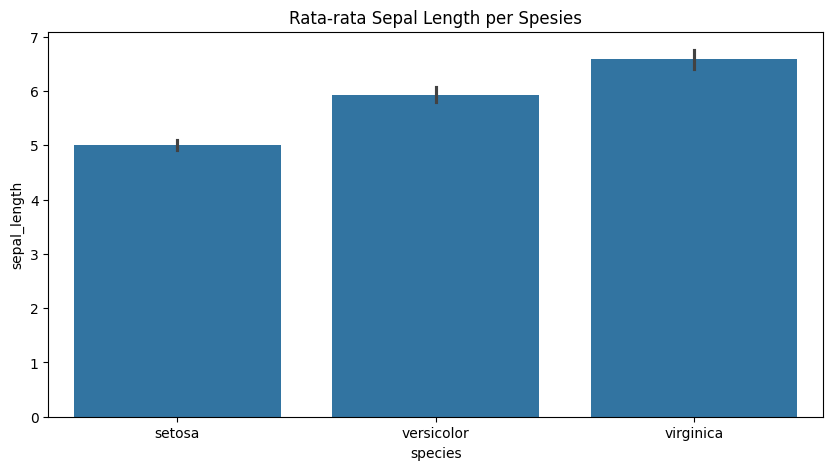

In [3]:
# Menghitung Statistik Deskriptif per Spesies (Mean, Std, Quantile)
stats_per_class = df.groupby('species').describe().T
display(stats_per_class)

# Visualisasi Rata-rata (Mean) per Spesies
plt.figure(figsize=(10, 5))
sns.barplot(x='species', y='sepal_length', data=df)
plt.title('Rata-rata Sepal Length per Spesies')
plt.show()

## 3. Identifikasi Outlier (Pencilan)
Outlier diidentifikasi menggunakan metode **Interquartile Range (IQR)**. Data dianggap outlier jika berada di luar batas bawah (LB) atau batas atas (UB).

**Rumus:**
- $IQR = Q3 - Q1$
- $Batas Bawah (LB) = Q1 - (1.5 \times IQR)$
- $Batas Atas (UB) = Q3 + (1.5 \times IQR)$

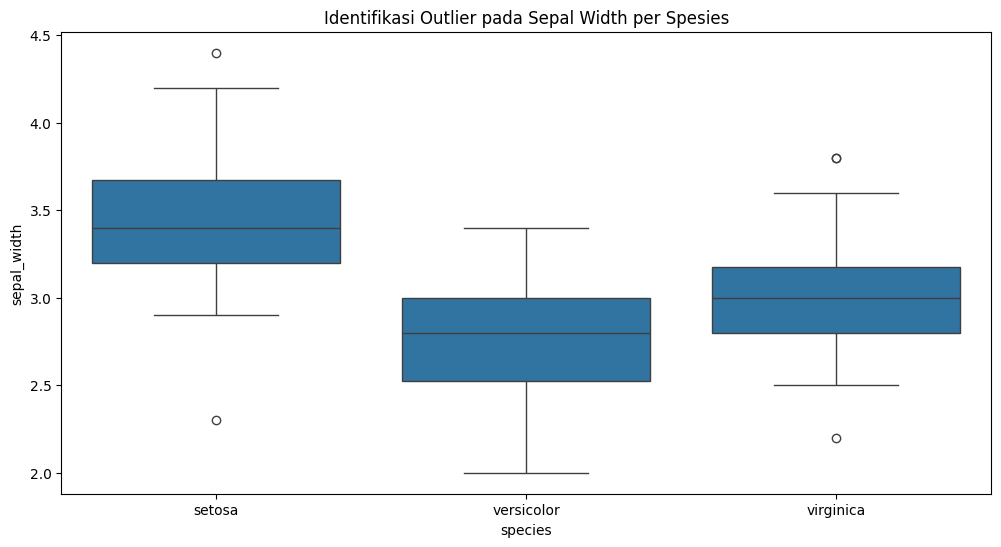

Analisis Outlier Setosa (Sepal Width):
Q1: 3.2, Q3: 3.6750000000000003, IQR: 0.4750000000000001
Batas Bawah (LB): 2.4875
Batas Atas (UB): 4.3875


In [4]:
# Visualisasi Outlier dengan Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='species', y='sepal_width', data=df)
plt.title('Identifikasi Outlier pada Sepal Width per Spesies')
plt.show()

# Contoh Perhitungan Outlier Manual (Spesies Setosa pada fitur Sepal Width)
setosa_data = df[df['species'] == 'setosa']['sepal_width']
q1 = setosa_data.quantile(0.25)
q3 = setosa_data.quantile(0.75)
iqr = q3 - q1
lb = q1 - (1.5 * iqr)
ub = q3 + (1.5 * iqr)

print(f"Analisis Outlier Setosa (Sepal Width):")
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Batas Bawah (LB): {lb}")
print(f"Batas Atas (UB): {ub}")

## 4. Kesimpulan Akhir
1. **Missing Values**: 0 (Data bersih, tidak butuh imputasi).
2. **Outlier**: Ditemukan pencilan pada fitur *Sepal Width* di spesies Setosa dan Virginica.
3. **Karakteristik**: Setiap spesies memiliki rentang nilai fitur yang berbeda (Setosa cenderung paling kecil pada fitur mahkota).
4. **Sumber Data**: Data divalidasi dari CSV, JSON, serta Database (PostgreSQL & MySQL).